<a href="https://colab.research.google.com/github/DSPL-B17/DSPL_hotelchainA/blob/main/XG_Boost_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **XG Boost Model**

In [1]:
!pip install xgboost
!pip install scikit-learn

In [2]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Model Training**

In [3]:
#Loading the cleaned train dataset
import pandas as pd
import numpy as ny
data = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/train_cleaned.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  27499 non-null  object 
 1   age                     27499 non-null  int64  
 2   ethnicity               27499 non-null  object 
 3   educational_level       27499 non-null  object 
 4   income                  27499 non-null  object 
 5   country_region          27499 non-null  object 
 6   hotel_type              27499 non-null  object 
 7   expected_checkin        27499 non-null  object 
 8   expected_checkout       27499 non-null  object 
 9   booking_date            27499 non-null  object 
 10  adults                  27499 non-null  float64
 11  children                27499 non-null  int64  
 12  babies                  27499 non-null  int64  
 13  meal_type               27499 non-null  object 
 14  visted_previously       27499 non-null

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import re

# Defining target variable
y = data['reservation_status']
X = data.drop('reservation_status', axis=1)

# Dropping identifier and date columns from features
columns_to_drop = [
    'reservation-id',
    'expected_checkin',
    'expected_checkout',
    'booking_date'
]
X = X.drop(columns=columns_to_drop, errors='ignore')

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Encoding target labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# Identifying categorical columns (object dtype) after splitting
categorical_cols_train = X_train.select_dtypes(include='object').columns
categorical_cols_test = X_test.select_dtypes(include='object').columns

# Applying One-Hot Encoding to training and testing sets
X_train_processed = pd.get_dummies(X_train, columns=categorical_cols_train, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols_test, drop_first=True)

# Aligning columns - essential for consistent feature sets across train and test
missing_in_test = set(X_train_processed.columns) - set(X_test_processed.columns)
for col in missing_in_test:
    X_test_processed[col] = 0

missing_in_train = set(X_test_processed.columns) - set(X_train_processed.columns)
for col in missing_in_train:
    X_train_processed[col] = 0

# Ensuring the order of columns is the same
X_test_processed = X_test_processed[X_train_processed.columns]

X_train = X_train_processed
X_test = X_test_processed

# Cleaning column names to remove problematic characters for XGBoost
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train = clean_col_names(X_train)
X_test = clean_col_names(X_test)

print("Shape of X_train after preprocessing:", X_train.shape)
print("Shape of X_test after preprocessing:", X_test.shape)
print("Unique values in y_train:", pd.Series(y_train).unique())
print("Unique values in y_test:", pd.Series(y_test).unique())

Shape of X_train after preprocessing: (19249, 51)
Shape of X_test after preprocessing: (8250, 51)
Unique values in y_train: [1 0 2]
Unique values in y_test: [1 0 2]


In [6]:
print("Unique values in y_train:", pd.Series(y_train).unique())

Unique values in y_train: [1 0 2]


**Model Development**

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [26]:
#Loading validation dataset
data = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/validation_cleaned.csv')

In [9]:
# Defining the base model with reduced complexity
xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=10,
    reg_alpha=0.5,
    tree_method="hist",
    verbosity=1
)

In [27]:
# Adjusting the hyperparameter search space
param_grid = {
    'max_depth': [2, 3],
    'learning_rate': [0.03, 0.05],
    'n_estimators': [30, 50],
    'subsample': [0.6, 0.7],
    'colsample_bytree': [0.6, 0.7],
    'reg_lambda': [5, 10],
    'reg_alpha': [0.2, 0.5]
}

In [29]:
# Using RandomizedSearchCV for faster tuning
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

In [30]:
# Training the model
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.7, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None, n_estimators=50,
                                           n_jobs=None, num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7],
                                        'learning_rate': [0.03, 0.05],
                                        'max_depth': [2, 3],
                                        'n_estimators': [30, 50],
                                        'reg_alpha': [0.2, 0.5],
                                        'reg_lambda': [5, 10],
                                        'subsample': [0.6, 0.7]},
                   scoring='accuracy', verbose=1)

In [32]:
#Best parameters from RandomizedSearchCV
print("Best Hyperparameters:", random_search.best_params_)

Best Hyperparameters: {'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.2, 'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [33]:
data = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/train_cleaned.csv')

In [16]:
# Evaluating the best model
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Getting accuracy
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Best Model Accuracy: {accuracy_best * 100:.2f}%")

Best Model Accuracy: 92.27%


**Confusion Matrix**

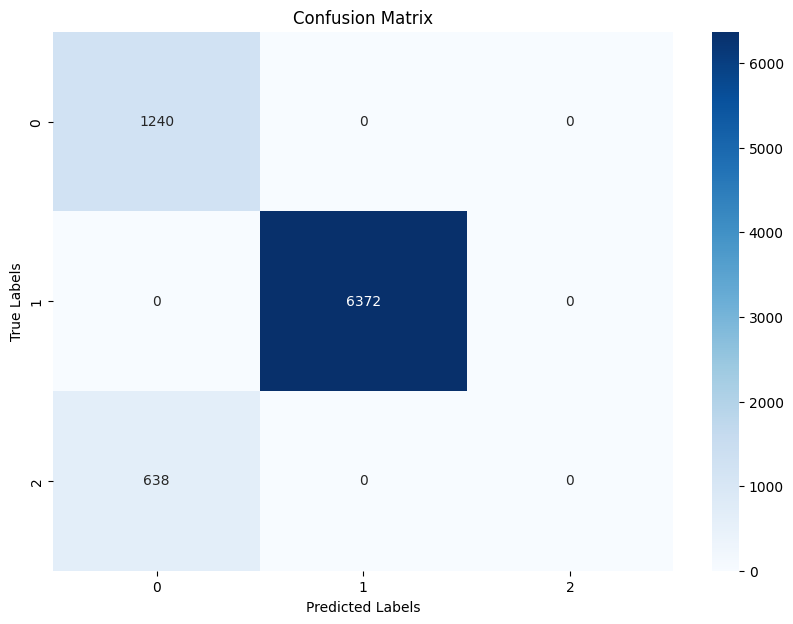

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(0, len(cm)), yticklabels=range(0, len(cm)))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


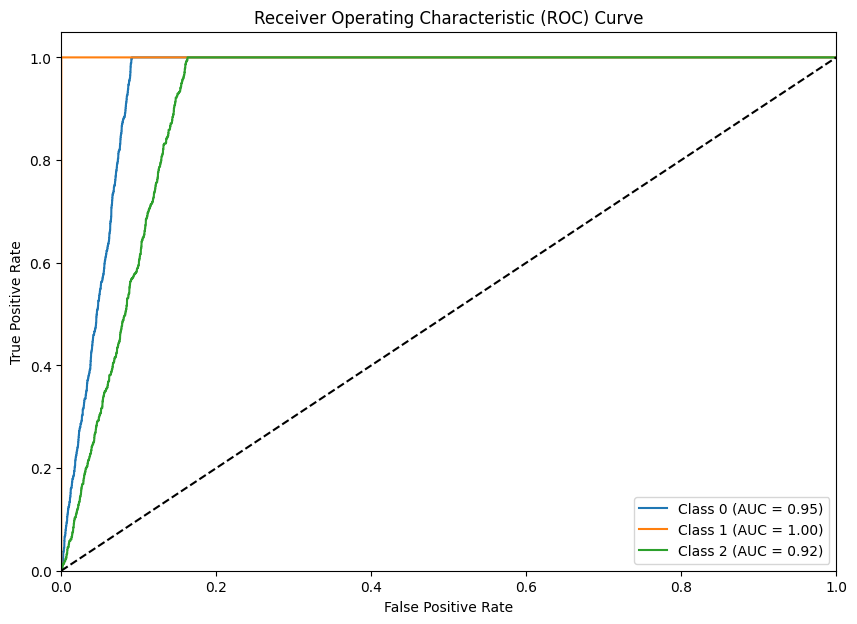

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarizing the output labels for multi-class classification
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5])
y_pred_prob = best_model.predict_proba(X_test)

# Calculating ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(cm)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curve
plt.figure(figsize=(10, 7))
for i in range(len(cm)):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()



**AUC Score**

In [19]:
# Calculating AUC Score
overall_auc = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
print(f'Overall AUC Score: {overall_auc:.4f}')


Overall AUC Score: 0.9575


In [20]:
# Evaluating on the training set
y_train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Evaluating on the test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Accuracy: 92.27%
Test Accuracy: 92.27%


**Cross-Validation:**

In [21]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean()}")

Cross-validation scores: [0.92285714 0.92285714 0.9225974  0.9225974  0.9228371 ]
Mean cross-validation score: 0.9227492382909375


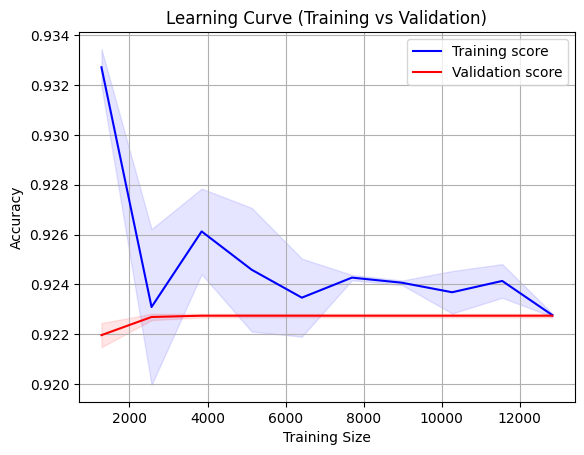

In [22]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

# Generating learning curve data
train_sizes, train_scores, validation_scores = learning_curve(
    best_model, X_train, y_train, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

# Calculating mean and standard deviation for train and validation scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(validation_scores, axis=1)
val_std = np.std(validation_scores, axis=1)

# Plotting the learning curve
plt.plot(train_sizes, train_mean, label="Training score", color="blue")
plt.plot(train_sizes, val_mean, label="Validation score", color="red")

# Filling the area between the mean +/- 1 std
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="red")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Training vs Validation)")
plt.legend(loc="best")
plt.grid(True)
plt.show()


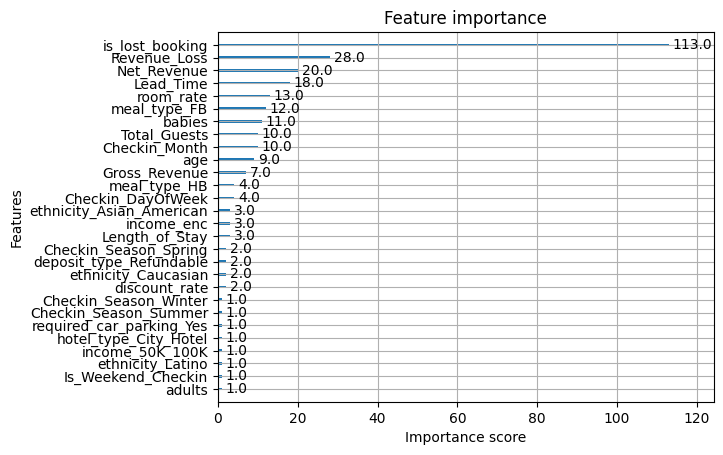

In [23]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# After fitting the model
plot_importance(best_model, importance_type='weight')
plt.show()


**Checking With Test Data**

In [ ]:
#Loading the test dataset
import pandas as pd
test_data = pd.read_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/test_cleaned.csv')

In [ ]:
import pandas as pd
import re

# If 'cluster_catgeory' exists in the test data, drop it to get features for prediction
if 'cluster_catgeory' in test_data.columns:
    X_test_raw = test_data.drop('cluster_catgeory', axis=1)
else:
    X_test_raw = test_data.copy()

# Dropping identifier and date columns, same as during training
columns_to_drop_real_world = [
    'reservation-id',
    'expected_checkin',
    'expected_checkout',
    'booking_date'
]
X_test_raw = X_test_raw.drop(columns=columns_to_drop_real_world, errors='ignore')

# Identifying categorical columns (object dtype) in the real-world test data
categorical_cols_real_world = X_test_raw.select_dtypes(include='object').columns

# Applying One-Hot Encoding
X_real_world_test_processed = pd.get_dummies(X_test_raw, columns=categorical_cols_real_world, drop_first=True)

# Cleaning column names to remove problematic characters for XGBoost
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_real_world_test_processed = clean_col_names(X_real_world_test_processed)

# Aligning columns with the training data (X_train)
missing_in_real_world_test = set(X_train.columns) - set(X_real_world_test_processed.columns)
for col in missing_in_real_world_test:
    X_real_world_test_processed[col] = 0

# Dropping any extra columns in real_world_test not present in X_train
extra_in_real_world_test = set(X_real_world_test_processed.columns) - set(X_train.columns)
X_real_world_test_processed = X_real_world_test_processed.drop(columns=list(extra_in_real_world_test), errors='ignore')

# Reordering columns to match X_train
X_real_world_test = X_real_world_test_processed[X_train.columns]

print(f"Shape of real-world test data for prediction after preprocessing: {X_real_world_test.shape}")
assert all(X_real_world_test.columns == X_train.columns), "Columns of real-world test data do not match training data after preprocessing!"

Shape of real-world test data for prediction after preprocessing: (4318, 51)


In [ ]:
# Making predictions using the best_model
real_world_predictions = best_model.predict(X_real_world_test)

# Displaying the first few predictions
print("First 10 real-world predictions (0 for not canceled, 1 for canceled):")
print(real_world_predictions[:10])

# Adding predictions back to the original real-world test data DataFrame
test_data['predicted_is_canceled'] = real_world_predictions
display(test_data.head())

First 10 real-world predictions (0 for not canceled, 1 for canceled):
[1 1 1 1 1 1 1 1 1 1]


,gender,age,ethnicity,educational_level,income,country_region,hotel_type,expected_checkin,expected_checkout,booking_date,...,Checkin_DayOfWeek,Is_Weekend_Checkin,Checkin_Season,Total_Guests,Is_Family,Guest_Type,income_enc,education_enc,Capacity_Exceeded,predicted_is_canceled
0,F,52,Latino,Grad,25K-50K,South,City Hotel,2016-11-18,2016-11-19,2016-10-28,...,4,0,Fall,6.0,1,Family,NaN,3,1,1
1,F,47,Latino,Grad,25K-50K,East,Airport Hotels,2016-11-18,2016-11-19,2016-08-06,...,4,0,Fall,3.0,1,Family,NaN,3,0,1
2,F,28,Asian American,Grad,<25K,East,City Hotel,2017-04-28,2017-05-01,2017-04-08,...,4,0,Spring,4.0,1,Family,0.0,3,0,1
3,F,65,Caucasian,High-School,25K-50K,South,Airport Hotels,2016-11-18,2016-11-20,2016-05-20,...,4,0,Fall,6.0,1,Family,NaN,1,1,1
4,M,45,African American,College,25K-50K,South,City Hotel,2016-11-18,2016-11-20,2016-10-31,...,4,0,Fall,4.0,1,Family,NaN,2,0,1


In [ ]:
from sklearn.metrics import classification_report

# Generating the classification report
report = classification_report(y_test, y_pred_best)

# Printing the classification report
print(report)

              precision    recall  f1-score   support

           0       0.66      1.00      0.80      1240
           1       1.00      1.00      1.00      6372
           2       0.00      0.00      0.00       638

    accuracy                           0.92      8250
   macro avg       0.55      0.67      0.60      8250
weighted avg       0.87      0.92      0.89      8250



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Saving the test_data DataFrame with predictions to a CSV file
test_data.to_csv('/content/drive/MyDrive/DSPL/GCW/Data/Processed/predictions.csv', index=False)

